In [1]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import preliz as pz

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='pytensor')

SEED = 12

# Parte 2: Modelos de Mezcla

Para esta parte se utilizó el dataset pizza_sales.csv, que contiene la información de ventas de pizzas.

In [2]:
pizza = pd.read_csv('../data/pizza_sales.csv', index_col=0)

In [ ]:
pizza.describe()

Al iniciar el análisis exploratorio, se observó que el dataset cuenta con 48.620 registros de ventas. La mayoría de los pedidos incluyen una sola pizza (`quantity` ≈ 1), con precios unitarios promedio cercanos a 16,5 y un máximo de 35,95. El precio total promedio (`total_price`) es de 16,8, aunque algunos pedidos alcanzan valores más altos al incluir varias pizzas o variedades de mayor costo.

Estos datos tienen una estructura de conteo, vamos a modelar las ventas por fecha.

In [3]:
pizza['order_date'] = pd.to_datetime(pizza['order_date'], format='%m/%d/%Y')

In [4]:
conteo = pizza.groupby(['order_date']).size().reset_index(name='n_orders')
conteo

,order_date,n_orders
0,2015-01-01,161
1,2015-01-02,160
2,2015-01-03,154
3,2015-01-04,106
4,2015-01-05,121
...,...,...
353,2015-12-27,87
354,2015-12-28,102
355,2015-12-29,77
356,2015-12-30,73


La tabla muestra la fecha y el número total de pedidos de ese día. En general, se observan entre unos 70 y 170 pedidos diarios, con bastante variación. Algunos días se piden muchas más pizzas, posiblemente fines de semana o fechas especiales como el 31 de diciembre.

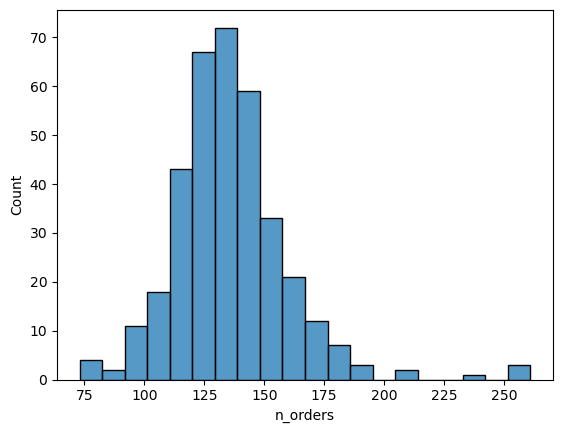

In [5]:
sns.histplot(conteo['n_orders'], bins=20);

Se observa que la mayoría de los días tienen entre 120 y 150 pedidos de pizza. La distribución es bastante concentrada alrededor de ese rango y cae rápidamente hacia los extremos, con pocos días de muy alta o muy baja cantidad de pedidos.

In [6]:
obs = conteo['n_orders'].values

In [15]:
obs.var(), obs.mean()

(np.float64(577.2991167566555), np.float64(135.81005586592178))

El promedio diario de pedidos es de unas 136 pizzas, y la varianza de 577 indica que los pedidos diarios fluctúan moderadamente alrededor de ese valor, es decir, hay cierta variabilidad en la demanda entre días.

## 1.
Plantear un modelo de mezcla finita (por ejemplo, mezcla de dos o más normales) y justificar la elección.

Buscamos identificar distintos tipos de días según la cantidad de pedidos, por ejemplo días tranquilos y días muy ajetreados. Como la variable representa conteos (número de pedidos diarios), un modelo adecuado es una mezcla de distribuciones Poisson, donde cada componente describe un tipo de día con su propia tasa media de pedidos.

In [38]:
k=2

with pm.Model() as poisson_mixture_model:
    μ = pm.Gamma('μ', mu=obs.mean(), sigma=25, shape=k)
    w = pm.Dirichlet('w', a=np.ones(k))

    comps = [pm.Poisson.dist(mu=μ[i]) for i in range(k)]

    x = pm.Mixture('x', w=w, comp_dists=comps, observed=obs)

    idata = pm.sample(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 59 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


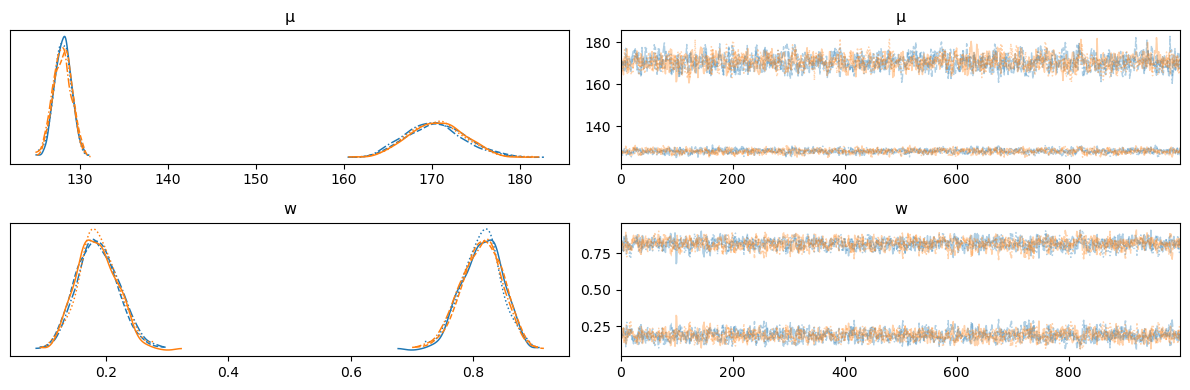

In [39]:
az.plot_trace(idata, var_names=['μ', 'w'])
plt.tight_layout();

Luego de analizar los gráficos, se observa que el modelo presenta problemas de identificabilidad, ya que los parámetros de los dos componentes se superponen y muestran simetría. En particular, las cadenas no convergen bien (la naranja se superpone con la azul y viceversa), lo que indica que el modelo no logra distinguir correctamente los grupos. Para solucionarlo, se usaron priors más informativos, asignando medias iniciales distintas. También se ordenaron los priors.

## 2.
Analizar la identificabilidad del modelo y discutir posibles problemas de simetría entre componentes.

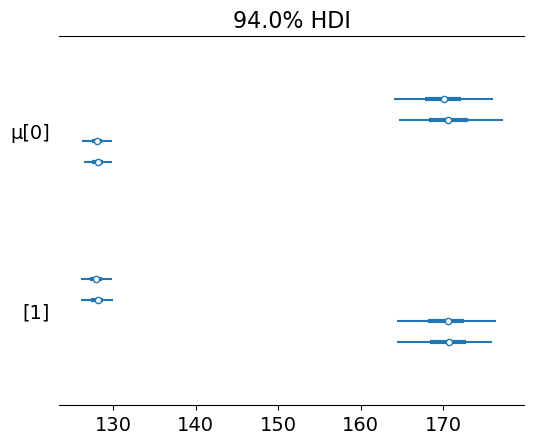

In [40]:
az.plot_forest(idata, var_names=['μ']);

Se define el μ así porque usamos los cuantiles de los datos para que cada componente del modelo empiece con una media diferente y representativa del rango de ventas, facilitando que el modelo identifique bien las zonas de baja y alta demanda.

In [ ]:
k=2
μ_μ = np.quantile(obs, np.linspace(0.1, 0.9, k))
μ_μ

array([111., 161.])

In [ ]:
with pm.Model() as poisson_mixture_model:
    μ = pm.Gamma('μ', mu=μ_μ, sigma=25, shape=k, transform=pm.distributions.transforms.ordered)
    w = pm.Dirichlet('w', a=np.ones(k))

    comps = [pm.Poisson.dist(mu=μ[i]) for i in range(k)]

    x = pm.Mixture('x', w=w, comp_dists=comps, observed=obs)

    idata = pm.sample(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 54 seconds.


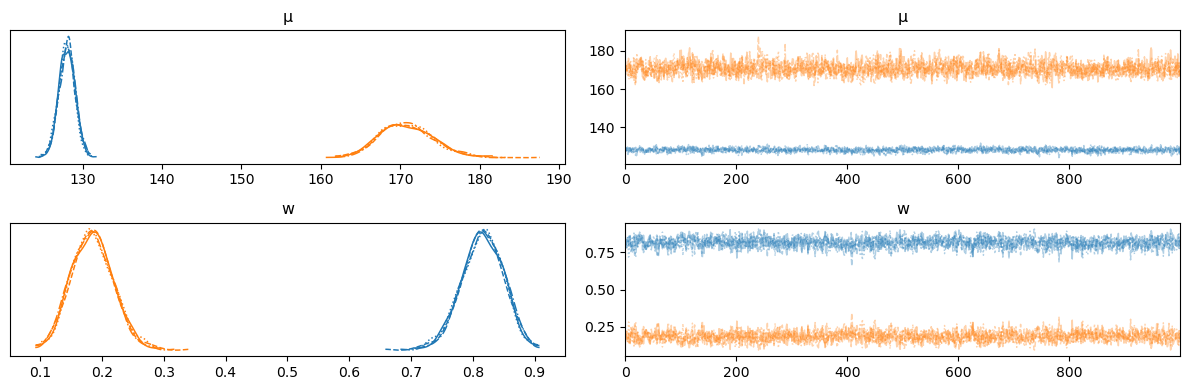

In [44]:
az.plot_trace(idata)
plt.tight_layout();

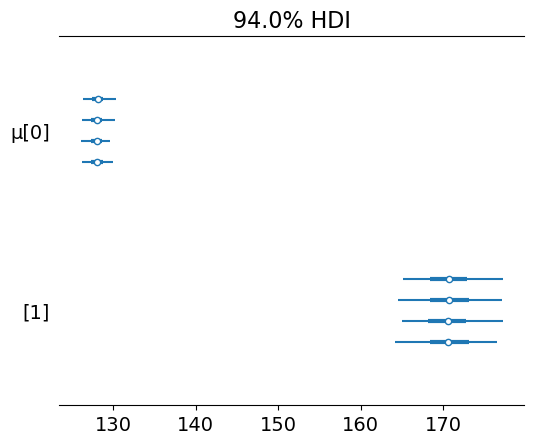

In [45]:
az.plot_forest(idata, var_names=['μ']);

In [46]:
az.summary(idata, kind="diagnostics")

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ[0],0.022,0.014,2059.0,2367.0,1.0
μ[1],0.085,0.054,1556.0,2373.0,1.0
w[0],0.001,0.001,1527.0,2331.0,1.0
w[1],0.001,0.001,1527.0,2331.0,1.0


Los resultados muestran que el modelo se ajustó correctamente, ya que todos los valores de r_hat son 1.0, lo que indica una buena convergencia de las cadenas. Las tasas μ[0] y μ[1] representan las medias de las dos Poisson del modelo

## 3.
Comparar distintos valores de K (número de componentes) y evaluar cuál describe mejor los datos.

In [7]:
Ks = [2, 3, 4, 5, 6]

idatas = []
modelos = []

for k in Ks:
    μ_μ = np.quantile(obs, np.linspace(0, 1, k))
    
    with pm.Model() as poisson_mixture_model:
        μ = pm.Gamma('μ', mu=μ_μ, sigma=25, shape=k, transform=pm.distributions.transforms.ordered)
        w = pm.Dirichlet('w', a=np.ones(k))

        comps = [pm.Poisson.dist(mu=μ[i]) for i in range(k)]

        x = pm.Mixture('x', w=w, comp_dists=comps, observed=obs)

        idata = pm.sample(target_accept=0.95, idata_kwargs={"log_likelihood": True}, random_seed=SEED)

        idatas.append(idata)
        modelos.append(poisson_mixture_model)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 124 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 137 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 184 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 231 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 433 seconds.


In [8]:
df_comp = az.compare({f'k={k}': idata for k, idata in zip(Ks, idatas)})
df_comp

c:\Users\nazar\anaconda3\envs\ei2\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
k=6,0,-1614.885281,9.761800,0.000000,0.970018,18.337603,0.000000,False,log
k=5,1,-1615.833421,10.408049,0.948140,0.000000,18.542383,0.355471,False,log
k=4,2,-1621.420907,11.140933,6.535626,0.000000,19.857032,3.339060,False,log
k=3,3,-1660.241976,16.509978,45.356694,0.000000,27.802789,13.754682,True,log
k=2,4,-1732.998509,18.871177,118.113228,0.029982,47.987122,34.807361,False,log


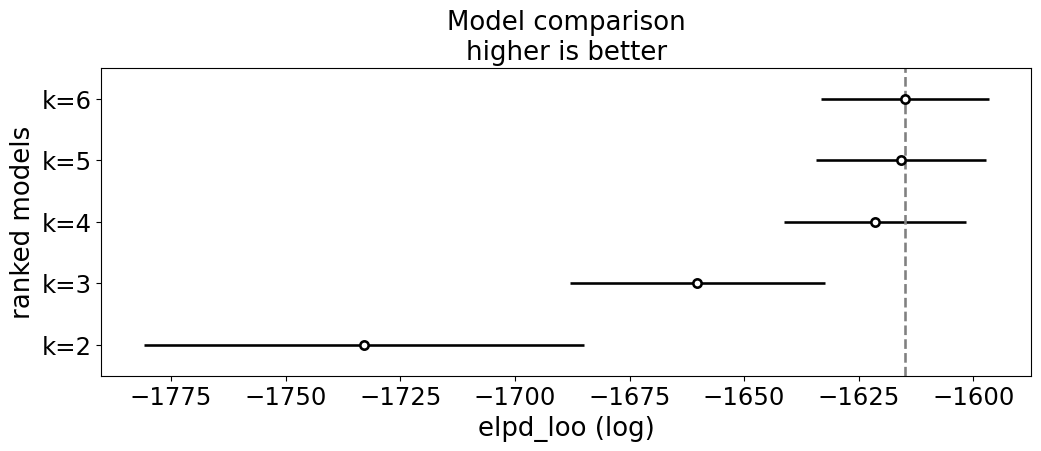

In [9]:
az.plot_compare(df_comp, figsize=(12, 4));

El modelo con seis grupos es el que mejor se ajusta a los datos, pero la diferencia con el modelo de cinco grupos es muy pequeña. Esto significa que ambos describen los datos casi igual de bien. En ese caso, conviene elegir el modelo con cuatro grupos, porque es más simple y logra un equilibrio entre buen ajuste y menor complejidad. Los modelos con menos grupos se ajustan peor y no logran representar bien la variabilidad de los pedidos diarios.

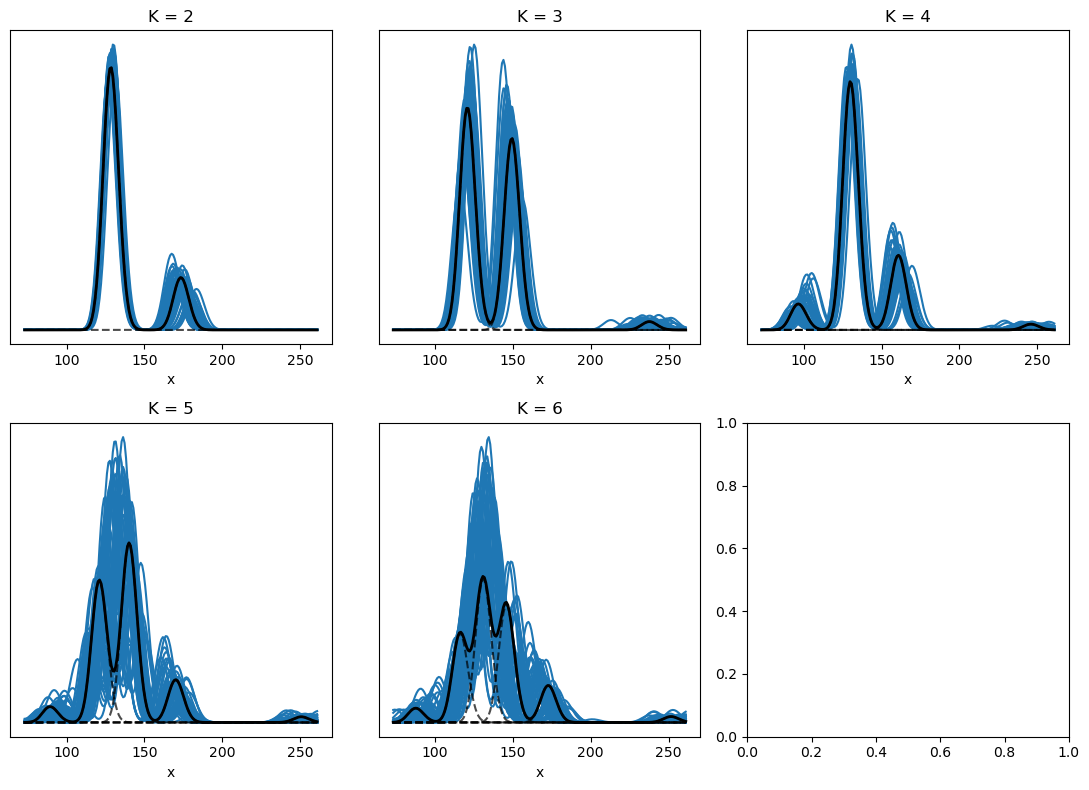

In [10]:
fig, ax = plt.subplots(2, 3, figsize=(11, 8))

ax = np.ravel(ax)
x = np.linspace(obs.min(), obs.max(), 200)
for idx, idata_x in enumerate(idatas):
    posterior_x = idata_x.posterior.stack(samples=("chain", "draw"))
    x_ = np.array([x] * Ks[idx]).T

    for i_ in np.random.randint(0, posterior_x.samples.size, size=50):
        dist = pz.Gamma(mu=posterior_x['μ'][:,i_], sigma=5)
        ax[idx].plot(x, np.sum(dist.pdf(x_) *  posterior_x['w'][:,i_].values, 1), 'C0')
 
    p_y = posterior_x['w'].mean("samples")
    dist = pz.Gamma(mu=posterior_x['μ'].mean("samples"), sigma=5)
    ax[idx].plot(x, np.sum(dist.pdf(x_) * p_y.values, 1), 'k', lw=2)
    ax[idx].plot(x, dist.pdf(x_) * p_y.values, 'k--', alpha=0.7)
         
    ax[idx].set_title('K = {}'.format(Ks[idx]))
    ax[idx].set_yticks([])
    ax[idx].set_xlabel('x')

plt.tight_layout();

Se procedió a graficar las distribuciones posteriores para cada modelo con distinto número de componentes (K). En los gráficos se observa cómo aumenta la complejidad del modelo al crecer K: con pocos componentes (K=2 o 3) el ajuste es limitado y no logra capturar bien toda la variabilidad de los datos, mientras que con más componentes (K=4, 5 y 6) las curvas se adaptan mejor a la forma de la distribución observada. Sin embargo, a partir de K=4 las diferencias son mínimas, lo que sugiere que ese número de componentes es suficiente para describir los distintos tipos de días en los pedidos.


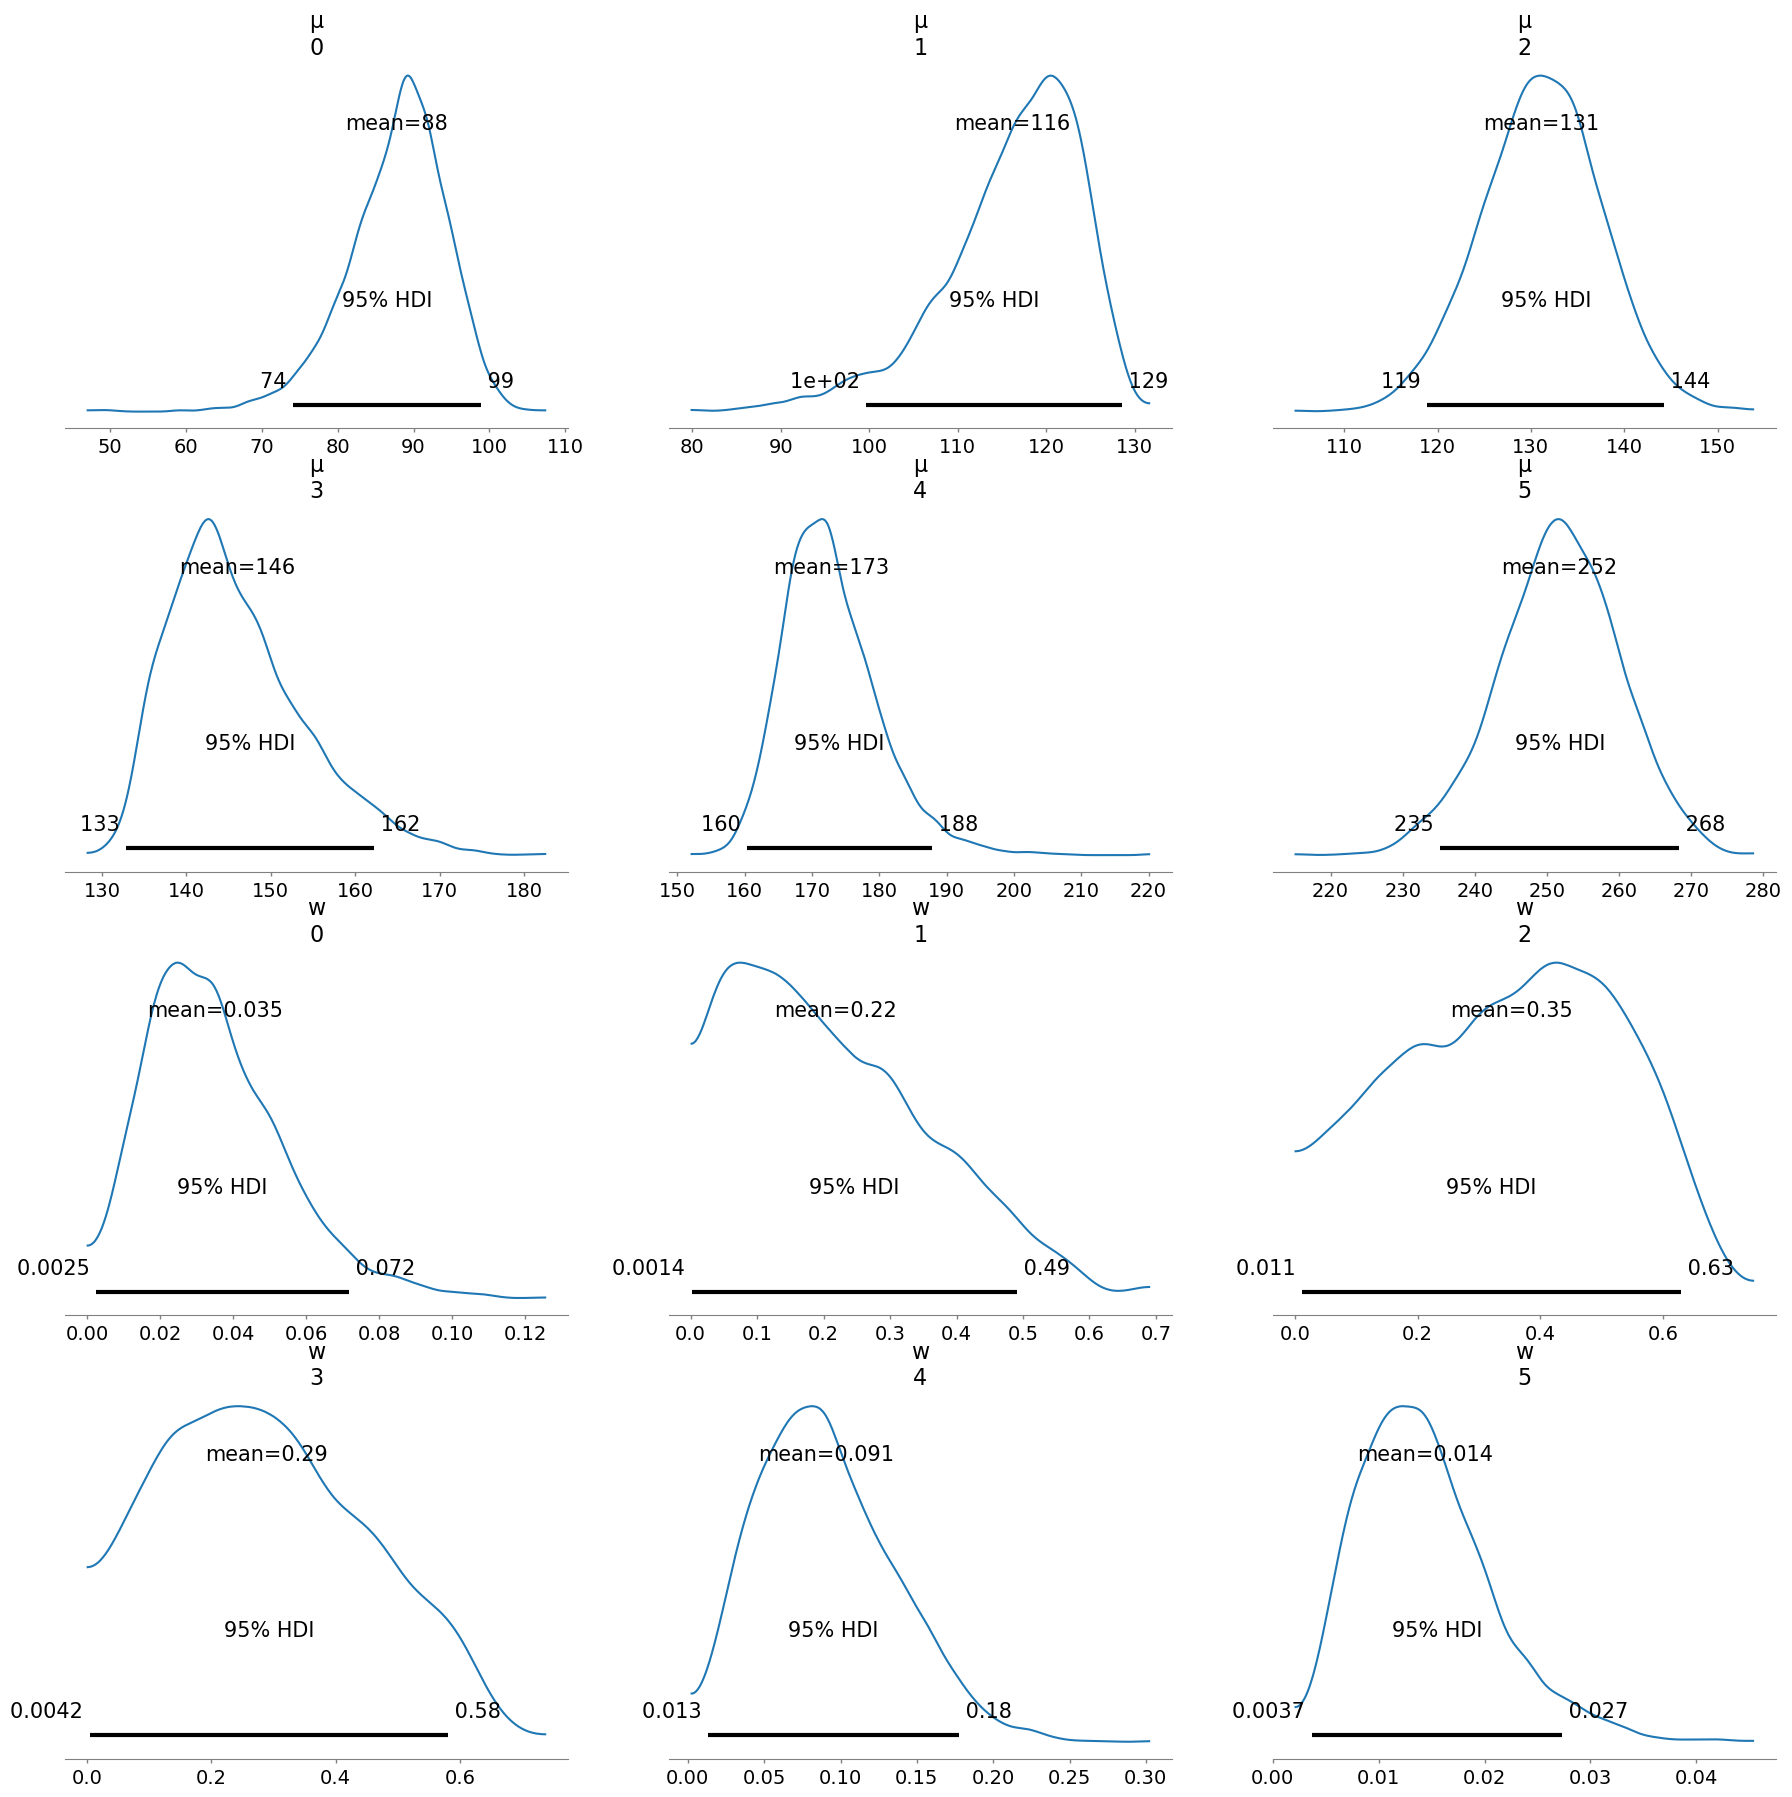

In [12]:
az.plot_posterior(idatas[4], hdi_prob=0.95);

El modelo de mezcla identifica seis tipos de días según la cantidad promedio de pedidos:

Días tranquilos, con unas 85 ventas (intervalo HDI 95% entre 73 y 96), que ocurren aproximadamente el 3,5% de los días.

Días algo más activos, con alrededor de 115 ventas, presentes en cerca del 19% de los días.

Días de demanda media, con unas 130 ventas, que representan alrededor del 33% de los días.

Días levemente por encima del promedio, con unas 142 ventas, que ocurren el 31% de los días.

Días muy activos, con cerca de 169 ventas, que se dan en torno al 12% de los días.

Finalmente, días excepcionales o picos de alta demanda, con aproximadamente 254 ventas, que aparecen solo en el 1,4% de los días.

En conjunto, el modelo refleja una estructura clara en la demanda: la mayoría de los días se concentran en niveles medios de pedidos, mientras que los días de muy baja o muy alta demanda son menos frecuentes.

In [13]:
for i, k in enumerate(Ks):
    modelo = modelos[i]
    idata = idatas[i]
    pm.sample_posterior_predictive(idata, model=modelo, random_seed=SEED, extend_inferencedata=True)

Sampling: [x]


Output()

Sampling: [x]


Output()

Sampling: [x]


Output()

Sampling: [x]


Output()

Sampling: [x]


Output()

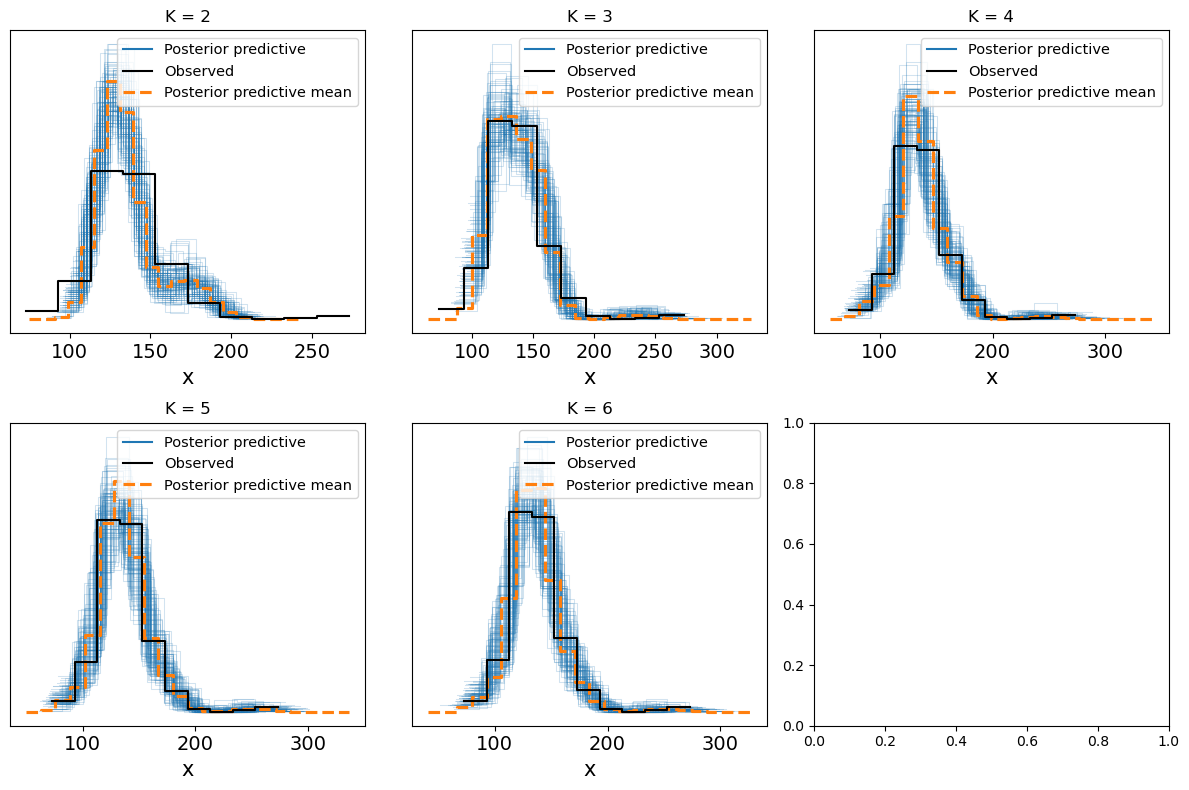

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes = np.ravel(axes)
for i, idata in enumerate(idatas):
    az.plot_ppc(idata, num_pp_samples=100, ax=axes[i])
    axes[i].set_title('K = {}'.format(Ks[i]))

plt.tight_layout();

El modelo con seis grupos logra el mejor ajuste, pero resulta demasiado específico: distingue entre tipos de días que probablemente representan situaciones muy puntuales, como un único día con demanda excepcionalmente alta (por ejemplo, una fecha festiva particular).

Por eso, optamos por el modelo con cuatro componentes, que es más general y dentro del margen de error estándar del modelo con seis (elpd_diff ≈ 6.5 con un error estándar de ≈ 19.9). Este modelo logra un equilibrio entre capacidad explicativa y simplicidad, capturando los principales patrones de la demanda —días tranquilos, días de alta demanda, fines de semana y días festivos— sin sobreajustar el comportamiento poco frecuente de algunos días extremos.


CHEQUEAR ENTONCES QUEDAMOS CON K =4?

El mejor modelo identifica 6 grupos, ¿cuales podrían ser?:

1. dia tranquilo (capaz lunes a miercoles)
2. dia demandante (capaz jueves y viernes)
3. fin de semana
4. día festivo tranquilo
5. día festivo demandante
6. día festivo muy demandante

esto es demasiado especifico (el día muy demandante es prbable que sea uno solo, accion de gracias)

entonces usamos k=4, porque es mas general y esta dentro del error estandar del modelo con 6 componentes (> PONER NUMEROS)

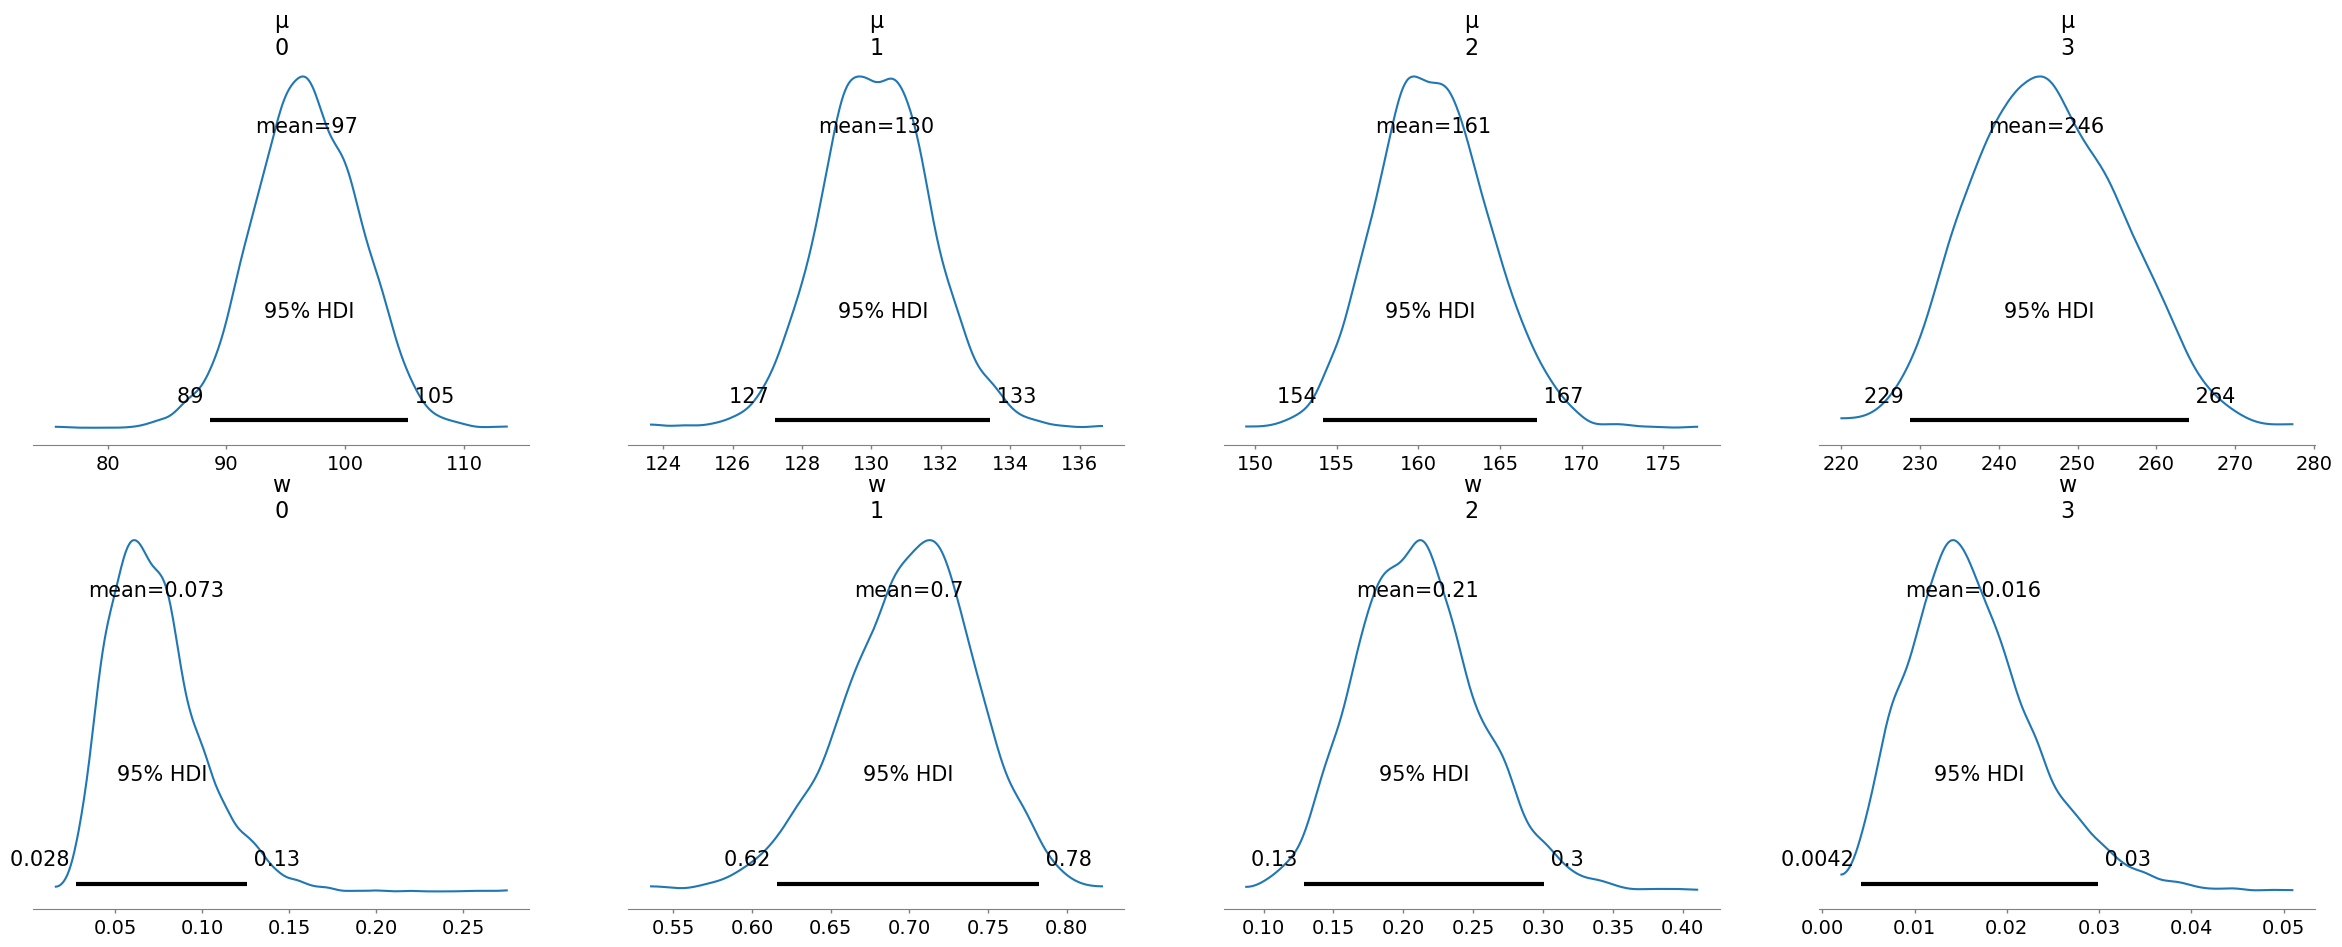

In [16]:
az.plot_posterior(idatas[2], hdi_prob=0.95);

1. Dia lento: 96 ventas el 7% de los días
2. Dia normal: 130 ventas el 70% de los días
3. Dia ajetreado: 161 ventas el 21% de los días
4. Día inusual: 248 ventas el 1.6% de los días

Vemos los días inusuales

In [17]:
conteo[conteo['n_orders']> 229]

,order_date,n_orders
184,2015-07-04,233
283,2015-10-15,258
323,2015-11-26,261
324,2015-11-27,259


Son festividades:  
Dia de la independencia  
Dia de la herencia latina  
Accion de gracias

Vemos otros días

In [18]:
conteo['day_of_week'] = conteo['order_date'].dt.day_name()

In [21]:
conteo.query('n_orders >=154 and n_orders <= 167').day_of_week.value_counts(normalize=True)

day_of_week
Friday       0.435897
Saturday     0.230769
Thursday     0.128205
Wednesday    0.102564
Tuesday      0.076923
Monday       0.025641
Name: proportion, dtype: float64

Son generalmente viernes y sabados.

Vemos días lentos

In [22]:
conteo.query('n_orders <= 105').day_of_week.value_counts(normalize=True)

day_of_week
Sunday       0.652174
Tuesday      0.130435
Monday       0.086957
Wednesday    0.086957
Saturday     0.043478
Name: proportion, dtype: float64

Son domingos y dias muy lentos